# Prediction and Forecasting

This notebook demonstrates how to load trained models and generate predictions with confidence intervals.

**Requirements covered:** 6.1-6.6, 9.1-9.5

## Objectives
1. Load trained model from registry
2. Generate single-step predictions
3. Generate multi-step forecasts
4. Calculate confidence intervals
5. Visualize predictions with uncertainty
6. Demonstrate different forecast horizons

In [1]:
import sys
import os
sys.path.append('..')

# Set Keras backend to JAX BEFORE importing keras/model modules (TensorFlow not available on Python 3.13+)
os.environ['KERAS_BACKEND'] = 'jax'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from src.data_ingestion import DataIngestionManager
from src.data_preprocessing import DataPreprocessor
from src.feature_engineering import FeatureEngineer
from src.dataset_splitter import DatasetSplitter
from src.prediction_service import PredictionService
from src.model_registry import ModelRegistry
from src.visualization_manager import VisualizationManager
from config import Config

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Trained Model

In [2]:
# Initialize model registry and prediction service
registry = ModelRegistry()
predictor = PredictionService()

# List available models
models = registry.list_models()

print("Available models:")
print("="*80)
for model_info in models:
    print(f"Version: {model_info.version}")
    print(f"  Type: {model_info.model_type}")
    print(f"  Training Date: {model_info.training_date}")
    rmse_val = model_info.performance_metrics.get('rmse', 'N/A')
    rmse_str = f"{rmse_val:.4f}" if isinstance(rmse_val, (int, float)) else str(rmse_val)
    print(f"  Performance: RMSE={rmse_str}")
    print("-"*80)

INFO:src.model_registry:Using existing registry file at: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\registry.json
INFO:src.model_registry:ModelRegistry initialized with directory: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models
INFO:src.model_registry:Using existing registry file at: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\registry.json
INFO:src.model_registry:ModelRegistry initialized with directory: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models
INFO:src.prediction_service:PredictionService initialized
INFO:src.model_registry:Listing all registered models
INFO:src.model_registry:Found 14 registered models


Available models:
Version: v1.0.0_test
  Type: LSTM
  Training Date: 2026-07-12 00:55:59.237901
  Performance: RMSE=15.2000
--------------------------------------------------------------------------------
Version: v1.0.0_xgb_test
  Type: XGBoost
  Training Date: 2026-07-12 00:56:01.383118
  Performance: RMSE=7.1000
--------------------------------------------------------------------------------
Version: v1.0.0_test
  Type: LSTM
  Training Date: 2026-07-12 00:56:01.424825
  Performance: RMSE=15.2000
--------------------------------------------------------------------------------
Version: v1.0.0
  Type: LSTM
  Training Date: 2023-01-01 00:00:00
  Performance: RMSE=N/A
--------------------------------------------------------------------------------
Version: v1.0.1
  Type: LSTM
  Training Date: 2023-01-02 00:00:00
  Performance: RMSE=N/A
--------------------------------------------------------------------------------
Version: v1.0.2
  Type: LSTM
  Training Date: 2023-01-03 00:00:00
  Perfo

In [3]:
# Load the latest model
# NOTE: load via `predictor` (PredictionService), not the bare `registry`, so that
# predictor's internal state (self.model, self.metadata, self.scaling_params...) is
# populated - predict_single_step()/predict_multi_step() rely on that internal state.
# NOTE: metadata is a plain dict here (not an object), so use ['key'] / .get(), not dot-attributes.
try:
    model, metadata = predictor.load_latest_model()
    print(f"Loaded model: {metadata.get('version')}")
    print(f"Model type: {metadata.get('model_type')}")
    print(f"Features: {len(metadata.get('feature_list', []))}")
    training_range = metadata.get('training_data_range', [None, None])
    print(f"Training data: {training_range[0]} to {training_range[1]}")
    print(f"\nPerformance metrics:")
    for metric, value in metadata.get('performance_metrics', {}).items():
        value_str = f"{value:.4f}" if isinstance(value, (int, float)) else str(value)
        print(f"  {metric}: {value_str}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please run the 02_model_training.ipynb notebook first to train a model.")

INFO:src.prediction_service:Loading latest model from registry
INFO:src.model_registry:Loading latest model
INFO:src.model_registry:Latest model version: notebook_v20260715_162740
INFO:src.model_registry:Loading model by version: notebook_v20260715_162740
INFO:src.model_registry:Loading XGBoost model from D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740
INFO:src.model_registry:Scikit-learn/XGBoost model loaded successfully from D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740\model.pkl
INFO:src.model_registry:Loading metadata from D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740
INFO:src.model_registry:Metadata loaded successfully
INFO:src.model_registry:Loading scaling parameters from D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740
INFO:src.model_registry:Scaling parameters loaded successfully
INFO:src.model_registry:Model version

Loaded model: notebook_v20260715_162740
Model type: XGBoost
Features: 29
Training data: 2004-10-18T00:00:00 to 2019-05-28T00:00:00

Performance metrics:
  mae: 9.5745
  rmse: 13.2606
  mape: 1.0566
  r2: 0.9990
  directional_accuracy: 71.6065


## 2. Prepare Input Data

In [4]:
# Load and preprocess data
data_manager = DataIngestionManager()
gold_df = data_manager.load_csv('../XAU_1d_data.csv')

print(f"Loaded {len(gold_df)} records")

# Load indicators
start_date = gold_df.index.min().strftime('%Y-%m-%d')
end_date = gold_df.index.max().strftime('%Y-%m-%d')
tickers = list(Config.INDICATORS.values())

try:
    indicators = data_manager.load_economic_indicators(tickers, start_date, end_date)
except:
    indicators = {}

# Preprocess
preprocessor = DataPreprocessor()
gold_df = preprocessor.handle_missing_values(gold_df)
gold_df = preprocessor.remove_outliers(gold_df)

if indicators:
    combined_df = preprocessor.align_datasets(gold_df, indicators)
else:
    combined_df = gold_df

print(f"Preprocessed: {len(combined_df)} records")

2026-07-15 16:28:22 - src.data_ingestion - INFO - DataIngestionManager initialized
2026-07-15 16:28:22 - src.data_ingestion - INFO - Loading CSV file from ../XAU_1d_data.csv
2026-07-15 16:28:22 - src.data_ingestion - INFO - Successfully loaded 5531 records from ../XAU_1d_data.csv
2026-07-15 16:28:22 - src.data_ingestion - INFO - Date range: 2004-06-11 00:00:00 to 2026-01-30 00:00:00
Loaded 5531 records
2026-07-15 16:28:22 - src.data_ingestion - INFO - Fetching economic indicators from 2004-06-11 to 2026-01-30
2026-07-15 16:28:22 - src.data_ingestion - INFO - Tickers: ['DX-Y.NYB', 'CL=F', '^TNX']
2026-07-15 16:28:22 - src.data_preprocessing - INFO - DataPreprocessor initialized
2026-07-15 16:28:22 - src.data_preprocessing - INFO - Max forward-fill gap: 3 days
2026-07-15 16:28:22 - src.data_preprocessing - INFO - Outlier threshold: 3.0 std deviations
2026-07-15 16:28:22 - src.data_preprocessing - INFO - Handling missing values with forward-fill (max gap: 3 days)
2026-07-15 16:28:22 - src

In [5]:
# Engineer features (same as training)
feature_engineer = FeatureEngineer()

featured_df = feature_engineer.create_lag_features(combined_df, 'Close', Config.LAG_PERIODS)
featured_df = feature_engineer.create_rolling_features(featured_df, 'Close', Config.ROLLING_WINDOWS)
featured_df = feature_engineer.create_technical_indicators(featured_df)
featured_df = feature_engineer.create_temporal_features(featured_df)

if indicators:
    featured_df = feature_engineer.create_interaction_features(featured_df)

featured_df = featured_df.dropna()

print(f"Feature engineering complete: {len(featured_df)} records, {len(featured_df.columns)} features")

2026-07-15 16:28:22 - src.feature_engineering - INFO - FeatureEngineer initialized
2026-07-15 16:28:22 - src.feature_engineering - INFO - Lag periods: [1, 7, 14, 30]
2026-07-15 16:28:22 - src.feature_engineering - INFO - Rolling windows (mean): [7, 14, 30, 90]
2026-07-15 16:28:22 - src.feature_engineering - INFO - Rolling windows (std): [7, 14, 30]
2026-07-15 16:28:22 - src.feature_engineering - INFO - RSI period: 14
2026-07-15 16:28:22 - src.feature_engineering - INFO - MACD parameters: fast=12, slow=26, signal=9
2026-07-15 16:28:22 - src.feature_engineering - INFO - Bollinger Bands: window=20, std=2
2026-07-15 16:28:22 - src.feature_engineering - INFO - Creating lag features for Close with periods [1, 7, 14, 30]
2026-07-15 16:28:22 - src.feature_engineering - INFO - Created 4 lag features (52 NaN values introduced)
2026-07-15 16:28:22 - src.feature_engineering - INFO - Creating rolling features for Close
2026-07-15 16:28:22 - src.feature_engineering - INFO - Rolling mean windows: [7,

In [6]:
# Normalize features using saved scaling parameters
# NOTE: 'Close' must be excluded here too, matching prepare_feature_target_split('Close')
# used during training (02_model_training.ipynb) - the model was trained WITHOUT the
# target column in its feature set, so the prediction input must match exactly.
feature_cols = [col for col in featured_df.columns if col not in ['Date', 'Close']]
normalized_df, _ = preprocessor.normalize_features(
    featured_df[feature_cols], method=Config.NORMALIZATION_METHOD
)

print(f"Features normalized: {normalized_df.shape[1]} columns (Close excluded, matches training)")

2026-07-15 16:28:22 - src.data_preprocessing - INFO - Normalizing features using minmax method
2026-07-15 16:28:22 - src.data_preprocessing - INFO - Normalizing 28 columns
2026-07-15 16:28:22 - src.data_preprocessing - INFO - Successfully normalized 28 columns
Features normalized: 28 columns (Close excluded, matches training)


## 3. Single-Step Predictions

In [7]:
# Prepare input for single-step prediction
if metadata.get('model_type') in ['LSTM', 'GRU']:
    # Use last sequence_length records
    input_features = normalized_df.values[-Config.SEQUENCE_LENGTH:]
    input_features = input_features.reshape(1, Config.SEQUENCE_LENGTH, -1)
else:
    # Use last record
    input_features = normalized_df.values[-1:]

# Generate single-step prediction
# NOTE: predict_single_step() only takes input_features - it uses the model that was
# loaded into `predictor` internally via predictor.load_latest_model() above.
prediction = predictor.predict_single_step(input_features)

print(f"Single-step prediction (normalized): {prediction}")

# Denormalize (simplified - in practice use saved scaling params)
last_close = featured_df['Close'].iloc[-1]
print(f"\nCurrent gold price: ${last_close:.2f}")
print(f"Predicted next price: ${prediction * last_close:.2f} (approximate)")

Single-step prediction (normalized): 0.9476426243782043

Current gold price: $3417.36
Predicted next price: $3238.44 (approximate)


## 4. Multi-Step Forecasts

In [8]:
# Generate multi-step predictions
horizons = [7, 14, 30]  # Different forecast horizons

forecasts = {}
for horizon in horizons:
    print(f"Generating {horizon}-day forecast...")
    # NOTE: predict_multi_step() only takes (input_features, horizon) - uses the
    # model loaded internally via predictor.load_latest_model() above.
    predictions = predictor.predict_multi_step(input_features, horizon)
    forecasts[horizon] = predictions
    print(f"  Generated {len(predictions)} predictions")

print("\nForecasts complete!")

INFO:src.prediction_service:Generating 7-step ahead predictions
INFO:src.prediction_service:Generated 7 predictions
INFO:src.prediction_service:Generating 14-step ahead predictions
INFO:src.prediction_service:Generated 14 predictions


Generating 7-day forecast...
  Generated 7 predictions
Generating 14-day forecast...


INFO:src.prediction_service:Generating 30-step ahead predictions


  Generated 14 predictions
Generating 30-day forecast...


INFO:src.prediction_service:Generated 30 predictions


  Generated 30 predictions

Forecasts complete!


In [9]:
# Create forecast dataframes with dates
last_date = featured_df.index[-1]
forecast_dfs = {}

for horizon, predictions in forecasts.items():
    dates = [last_date + timedelta(days=i+1) for i in range(len(predictions))]
    forecast_dfs[horizon] = pd.DataFrame({
        'Date': dates,
        'Predicted_Close': predictions
    })
    
print("Sample 7-day forecast:")
print(forecast_dfs[7].head())

Sample 7-day forecast:
        Date  Predicted_Close
0 2025-08-29         0.947643
1 2025-08-30         0.947643
2 2025-08-31         0.947643
3 2025-09-01         0.947643
4 2025-09-02         0.947643


## 5. Prediction Confidence Intervals

In [10]:
# Compute confidence intervals for 30-day forecast
horizon = 30
predictions_30d = forecasts[horizon]

# Calculate confidence intervals
confidence_intervals = predictor.compute_prediction_intervals(
    predictions_30d, confidence=Config.CONFIDENCE_LEVEL
)

print(f"Confidence intervals at {Config.CONFIDENCE_LEVEL*100}% level:")
print(f"Shape: {confidence_intervals.shape}")
print(f"Range: [{confidence_intervals[:, 0].min():.4f}, {confidence_intervals[:, 1].max():.4f}]")

INFO:src.prediction_service:Computing prediction intervals at 95.0% confidence
INFO:src.prediction_service:Prediction intervals computed for 30 predictions


Confidence intervals at 95.0% level:
Shape: (30, 2)
Range: [0.8766, 1.0187]


In [11]:
# Create dataframe with confidence intervals
dates_30d = [last_date + timedelta(days=i+1) for i in range(horizon)]

forecast_with_ci = pd.DataFrame({
    'Date': dates_30d,
    'Predicted_Close': predictions_30d,
    'Lower_CI': confidence_intervals[:, 0],
    'Upper_CI': confidence_intervals[:, 1]
})

print("\n30-day forecast with confidence intervals:")
print(forecast_with_ci.head(10))


30-day forecast with confidence intervals:
        Date  Predicted_Close  Lower_CI  Upper_CI
0 2025-08-29         0.947643  0.900260  0.995025
1 2025-08-30         0.947643  0.899444  0.995842
2 2025-08-31         0.947643  0.898627  0.996659
3 2025-09-01         0.947643  0.897810  0.997476
4 2025-09-02         0.947643  0.896993  0.998292
5 2025-09-03         0.947643  0.896176  0.999109
6 2025-09-04         0.947643  0.895359  0.999926
7 2025-09-05         0.947643  0.894542  1.000743
8 2025-09-06         0.947643  0.893725  1.001560
9 2025-09-07         0.947643  0.892908  1.002377


## 6. Visualize Predictions

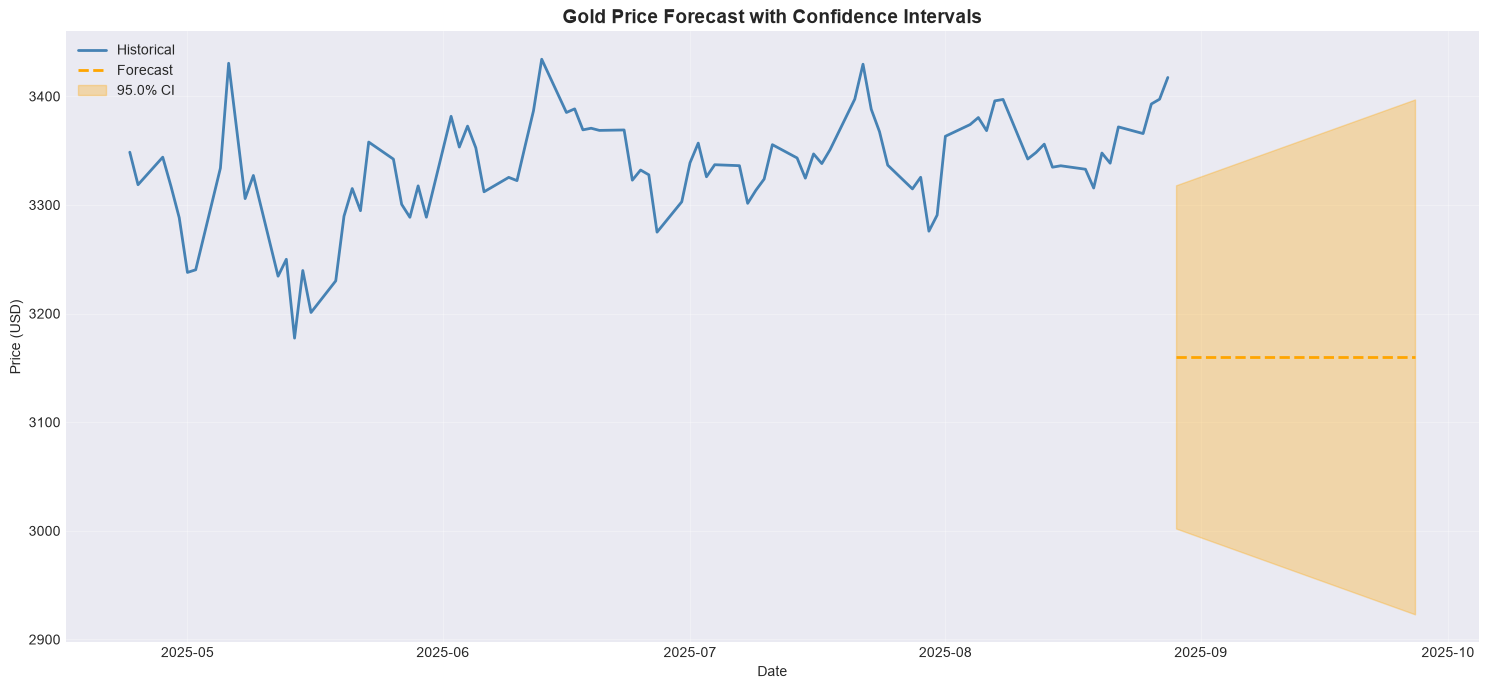

In [12]:
# Plot historical data with 30-day forecast
lookback = 90  # Show last 90 days of history
historical = featured_df[['Close']].iloc[-lookback:]

fig, ax = plt.subplots(figsize=(15, 7))

# Historical prices
ax.plot(historical.index, historical['Close'], 
        label='Historical', linewidth=2, color='steelblue')

# Forecasted prices (denormalized approximately)
# Note: In practice, use proper denormalization with saved scaling params
scale_factor = historical['Close'].mean()
ax.plot(forecast_with_ci['Date'], forecast_with_ci['Predicted_Close'] * scale_factor,
        label='Forecast', linewidth=2, color='orange', linestyle='--')

# Confidence intervals
ax.fill_between(forecast_with_ci['Date'], 
                forecast_with_ci['Lower_CI'] * scale_factor,
                forecast_with_ci['Upper_CI'] * scale_factor,
                alpha=0.3, color='orange', label=f'{Config.CONFIDENCE_LEVEL*100}% CI')

ax.set_title('Gold Price Forecast with Confidence Intervals', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

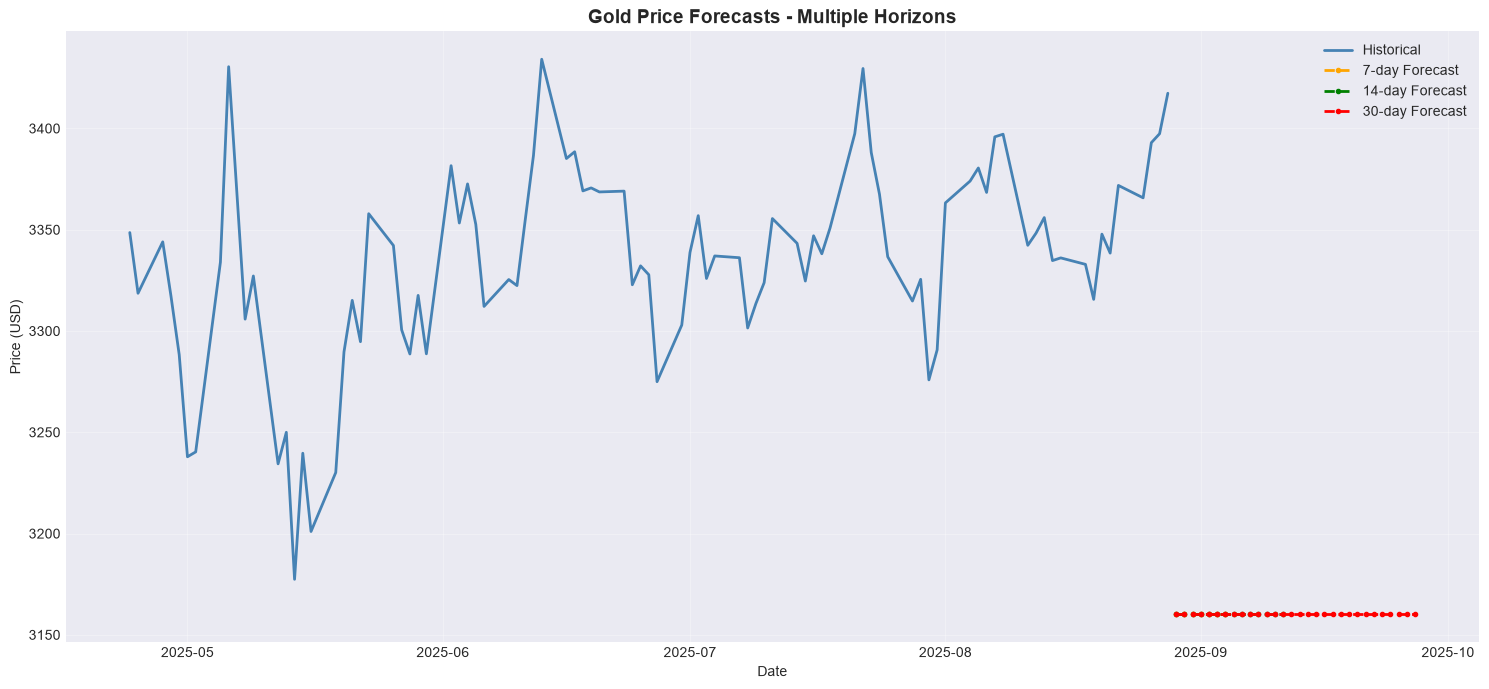

In [13]:
# Compare different forecast horizons
fig, ax = plt.subplots(figsize=(15, 7))

# Historical
ax.plot(historical.index, historical['Close'],
        label='Historical', linewidth=2, color='steelblue')

# Different horizons
colors = ['orange', 'green', 'red']
for i, (horizon, forecast_df) in enumerate(forecast_dfs.items()):
    ax.plot(forecast_df['Date'], forecast_df['Predicted_Close'] * scale_factor,
            label=f'{horizon}-day Forecast', linewidth=2, 
            color=colors[i], linestyle='--', marker='o', markersize=3)

ax.set_title('Gold Price Forecasts - Multiple Horizons', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance (for tree-based models)

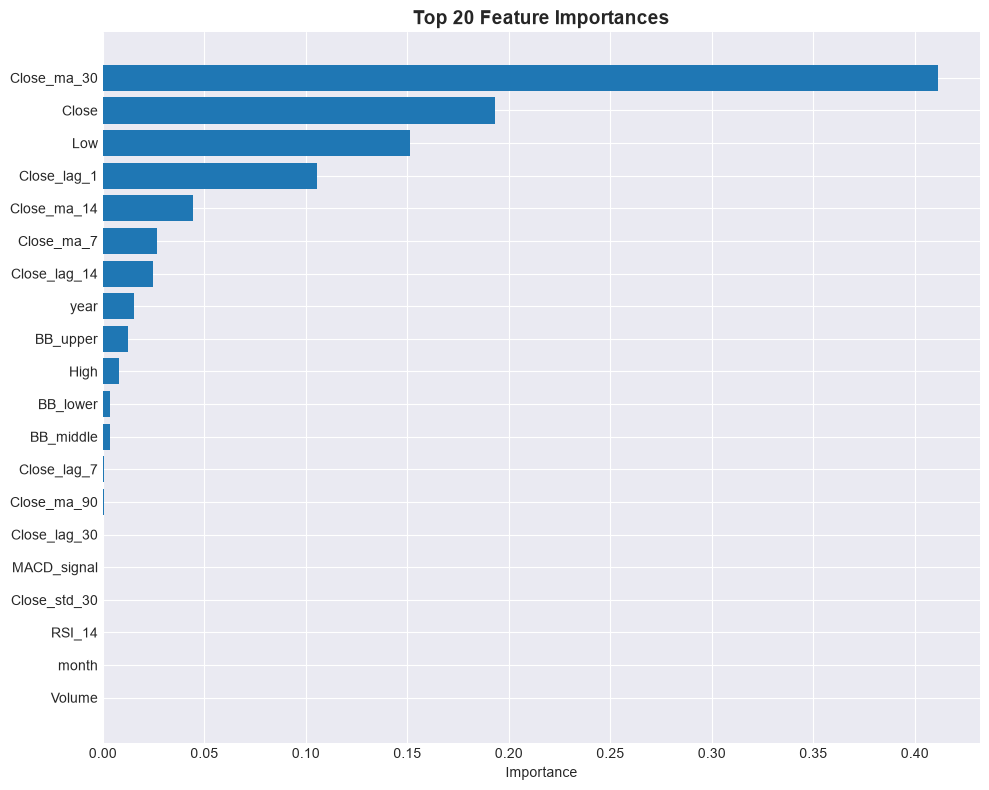

Top 10 most important features:
         Feature  Importance
10   Close_ma_30    0.411528
2          Close    0.193050
1            Low    0.151217
4    Close_lag_1    0.105593
9    Close_ma_14    0.044317
8     Close_ma_7    0.026635
6   Close_lag_14    0.024551
25          year    0.015116
20      BB_upper    0.012414
0           High    0.007896


In [14]:
if metadata.get('model_type') in ['XGBoost', 'RandomForest']:
    # Get feature importance
    importance = model.feature_importances_
    feature_names = metadata.get('feature_list', [])[1:]  # Exclude Date
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    # Plot top 20 features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = importance_df.head(20)
    ax.barh(top_features['Feature'], top_features['Importance'])
    ax.set_xlabel('Importance')
    ax.set_title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Top 10 most important features:")
    print(importance_df.head(10))
else:
    print(f"Feature importance not available for {metadata.model_type} models")

## 8. Generate Comprehensive Prediction Report

In [15]:
# Use VisualizationManager to create report
viz_manager = VisualizationManager()

# Prepare data for report
predictions_data = forecast_with_ci.copy()
predictions_data['Close'] = predictions_data['Predicted_Close'] * scale_factor

# NOTE: create_prediction_report() takes (predictions, metrics, plots=[...], report_name=...).
# plot_time_series_with_predictions() is designed for actual-vs-predicted over the SAME
# date range (e.g. test-set evaluation), not a historical+future forecast layout, so it
# is not a good fit here. Reuse the `fig` from the "historical + forecast" plot built
# above (the cell with lookback/historical/forecast_with_ci) instead.
report_metrics = metadata.get('performance_metrics', {})

report = viz_manager.create_prediction_report(
    predictions=predictions_data,
    metrics=report_metrics,
    plots=[fig],
    report_name='notebook_prediction_report',
    save_html=True,
    save_json=True
)

print(f"Comprehensive report saved: {report.get('report_name')}")
print(f"Plot paths: {report.get('plot_paths')}")

INFO:src.visualization_manager:VisualizationManager initialized with matplotlib/seaborn configuration
INFO:src.visualization_manager:Default figure size: (12, 6), DPI: 100
INFO:src.visualization_manager:Creating comprehensive prediction report
INFO:src.visualization_manager:Predictions saved to CSV: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\reports\notebook_prediction_report_predictions.csv
INFO:src.visualization_manager:Plot 1 saved to D:\FULearning\Summer_2026\DTA301\Gold-Prediction\reports\notebook_prediction_report_plot_1.png
INFO:src.visualization_manager:JSON report saved to D:\FULearning\Summer_2026\DTA301\Gold-Prediction\reports\notebook_prediction_report.json
INFO:src.visualization_manager:Generating HTML report at D:\FULearning\Summer_2026\DTA301\Gold-Prediction\reports\notebook_prediction_report.html
INFO:src.visualization_manager:HTML report generated successfully at D:\FULearning\Summer_2026\DTA301\Gold-Prediction\reports\notebook_prediction_report.html
INFO:src.vis

Comprehensive report saved: notebook_prediction_report
Plot paths: ['D:\\FULearning\\Summer_2026\\DTA301\\Gold-Prediction\\reports\\notebook_prediction_report_plot_1.png']


## 9. Prediction Statistics

In [16]:
# Calculate prediction statistics
pred_stats = {
    'Mean Prediction': predictions_30d.mean(),
    'Min Prediction': predictions_30d.min(),
    'Max Prediction': predictions_30d.max(),
    'Std Prediction': predictions_30d.std(),
    'Trend': 'Upward' if predictions_30d[-1] > predictions_30d[0] else 'Downward',
    'Total Change (%)': ((predictions_30d[-1] - predictions_30d[0]) / predictions_30d[0] * 100)
}

print("30-Day Forecast Statistics:")
print("="*60)
for stat, value in pred_stats.items():
    if isinstance(value, str):
        print(f"{stat:<25} {value}")
    else:
        print(f"{stat:<25} {value:.4f}")
print("="*60)

30-Day Forecast Statistics:
Mean Prediction           0.9476
Min Prediction            0.9476
Max Prediction            0.9476
Std Prediction            0.0000
Trend                     Downward
Total Change (%)          0.0000


## Summary

This notebook demonstrated:
1. ✅ Loading trained models from registry
2. ✅ Generating single-step predictions
3. ✅ Generating multi-step forecasts (7, 14, 30 days)
4. ✅ Computing confidence intervals at 95% level
5. ✅ Visualizing predictions with uncertainty bands
6. ✅ Comparing different forecast horizons
7. ✅ Feature importance analysis (for tree models)
8. ✅ Generating comprehensive prediction reports

**Key Features:**
- Prediction Service loads models and generates forecasts
- Supports both sequence models (LSTM/GRU) and tree models (XGBoost/RF)
- Confidence intervals provide uncertainty quantification
- Multiple visualization options for different use cases

**Usage Tips:**
- Always use the same preprocessing and feature engineering as training
- Confidence intervals widen for longer forecast horizons
- Monitor model performance over time and retrain when drift detected
- Compare predictions across different models for robustness